In [1]:
'''
ML Pipeline for Gridded Precip Project (XGBoost) - both IDW and kriging input options

Overview and Motivation
The goal of this workflow is to integrate heterogeneous observational, satellite, and climatological datasets into a unified, physically informed ML framework
for predicting precipitation phase (rain, snow, or mixed). Because direct precipitation-phase observations are sparse and unevenly distributed in space and time,
we adopt a weakly supervised labeling approach using an interpolated MRoS proxy, combined with spatially blocked ML training to handle prediction across complex terrain.

1. Gridded surface preprocessing
All predictor layers are aligned to a common coordinate reference system, grid resolution, and timestamp index.
Output: Stacked gridded predictor datasets (NetCDF), one layer per variable per hour.

2. Precip phase labeling via MRoS proxy
The interpolated MRoS proxy surface is converted into discrete phase classes
The MRoS proxy is used exclusively for labeling and is not included as a predictor to avoid target leakage.
Output: A space-time mask identifying gridcell-hours with usable phase labels.

3. Feature table construction:
Transform gridded data back into tabular format required for ML processing.
Output: a tabular dataset (e.g., parquet) suitable for ML training

4. Spatial blocking to split data
Motivation: spatial blocking accounts for spatial autocorrelation and avoids overestimated performance that arise from random splits.

5. ML model training and class structure
XGBoost multi-class classifier:
- Target variable: 3-class phase (snow = 0, rain = 1, mix = 2).
- The model is trained directly using a multi-class softmax objective (multi:softprob) with three output nodes.
- The model predicts class probabilities:
--- p_snow, p_rain, p_mix (which sum to 1).
- A grid cell-hour is classified as the class with highest probability (argmax):
--- snow → if p_snow is largest
--- rain → if p_rain is largest
--- mix → if p_mix is largest
- Mixed phase is treated as a true thermodynamic class in the training data rather than as a post hoc uncertainty category.
- Class imbalance is handled using balanced class weights combined with label-confidence weighting and transition-window upweighting (0–4°C wet-bulb regime).
- Model hyperparameter tuning is performed on the validation set (tree depth, learning rate, subsampling, min_child_weight, etc.).
- Stopping criteria via early stopping on validation multiclass log loss (mlogloss).

6. Model evaluation and performance
Model performance is evaluated on a fully held-out test set using 3-class metrics (confusion matrix, classification report, multiclass log loss).

7. Exported outputs
The final exported test predictions (parquet format) contain:
-time, x, y: spatial-temporal coordinates
-phase: original 3-class label (0 = snow, 1 = rain, 2 = mix)
-prediction: predicted 3-class output (0 = snow, 1 = rain, 2 = mix)
-p_snow: predicted probability of snow
-p_rain: predicted probability of rain
-p_mix: predicted probability of mix
-max_prob: model confidence in dominant class (max of the three probabilities)
-entropy: information-theoretic uncertainty metric
-block_id: spatial block identifier used for cross-validation
'''

'\nML Pipeline for Gridded Precip Project (XGBoost) - both IDW and kriging input options\n\nOverview and Motivation\nThe goal of this workflow is to integrate heterogeneous observational, satellite, and climatological datasets into a unified, physically informed ML framework\nfor predicting precipitation phase (rain, snow, or mixed). Because direct precipitation-phase observations are sparse and unevenly distributed in space and time,\nwe adopt a weakly supervised labeling approach using an interpolated MRoS proxy, combined with spatially blocked ML training to handle prediction across complex terrain.\n\n1. Gridded surface preprocessing\nAll predictor layers are aligned to a common coordinate reference system, grid resolution, and timestamp index.\nOutput: Stacked gridded predictor datasets (NetCDF), one layer per variable per hour.\n\n2. Precip phase labeling via MRoS proxy\nThe interpolated MRoS proxy surface is converted into discrete phase classes\nThe MRoS proxy is used exclusive

Key updates:
- removing overlapping air temp and dew temp variables from different data sources. Instead, introducing anomaly air temp and dew temp from PRISM compared to station data.
- thresholding update: implementing <=20 snow and >= rain... with remainder as mix. Introducing label confidence values.
- removing prism_ppt_daily
- including label confidence weights on top of existing class rebalancing. Also, transition-window upweight (focus on 0–4°C wet-bulb)

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import json
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.metrics import brier_score_loss
from scipy.stats import entropy


In [3]:
BASE_DIR = Path().resolve().parent  # current working dir
print("BASE_DIR:", BASE_DIR)

ML_DIR = BASE_DIR / "ML_pipeline"
print("ML_DIR:", ML_DIR)

DATA_DIR = Path("C:/Users/EmmaGolub/Desktop/MRoS_local/local_data") # change to USER's local folder where large data files are stored
print("DATA_DIR:", DATA_DIR)

PATHS = {
    "IDW": DATA_DIR / "IDW/hourly_predictors_1km_IDW_full.nc",
    "kriging": DATA_DIR / "kriging/hourly_predictors_1km_kriging_v1_final.nc",
    "imerg": BASE_DIR / "outputs/resampled_grids/imerg_hourly_1km.nc",
    "prism": BASE_DIR / "outputs/resampled_grids/prism_hourly_1km.nc",
}

interp_type = "kriging" # "IDW" or "kriging"

if interp_type == "IDW":
    interp_type_folder = "withIDW_v4"
elif interp_type == "kriging":
    interp_type_folder = "withKriging_v4"

SETUP_DIR = DATA_DIR / "ML_pipeline/compiled_input_predictors" / interp_type_folder # save locally because large files
SETUP_DIR.mkdir(exist_ok=True)
print("SETUP_DIR:", SETUP_DIR)

MODEL_OUT_DIR = ML_DIR / "model_artifacts" / interp_type_folder
MODEL_OUT_DIR.mkdir(exist_ok=True)
print("MODEL_OUT_DIR:", MODEL_OUT_DIR)

GRAPHICS_DIR = MODEL_OUT_DIR / "graphics"
GRAPHICS_DIR.mkdir(exist_ok=True)
print("GRAPHICS_DIR:", GRAPHICS_DIR)


BASE_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype
ML_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline
DATA_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\local_data
SETUP_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\local_data\ML_pipeline\compiled_input_predictors\withKriging_v4
MODEL_OUT_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withKriging_v4
GRAPHICS_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withKriging_v4\graphics


## Step 1: Preprocessing & QAQC

### 1a: Load datasets
Load interpolated predictors (IDW/kriging), IMERG, and PRISM. Sync by time and grid before proceeding.


In [4]:
## Checking time synchronization -------------------------------------------------

ds_IDW = xr.open_dataset(PATHS["IDW"])
ds_kriging = xr.open_dataset(PATHS["kriging"])
ds_imerg = xr.open_dataset(PATHS["imerg"])
ds_prism = xr.open_dataset(PATHS["prism"])

for name, ds in {
    "IDW": ds_IDW,
    "kriging": ds_kriging,
    "IMERG": ds_imerg,
    "PRISM": ds_prism,
}.items():
    print(f"\n{name}")
    print(ds)

def summarize_time(ds, name):
    t = ds["time"]
    print(f"\n{name} time summary:")
    print("  start:", pd.to_datetime(t.values[0]))
    print("  end:  ", pd.to_datetime(t.values[-1]))
    print("  n:", t.size)
    print("  freq guess:", pd.infer_freq(pd.to_datetime(t.values[:10])))

summarize_time(ds_IDW, "IDW")
summarize_time(ds_kriging, "kriging")
summarize_time(ds_imerg, "IMERG")
summarize_time(ds_prism, "PRISM")



IDW
<xarray.Dataset> Size: 5GB
Dimensions:         (time: 5832, y: 251, x: 142)
Coordinates:
  * y               (y) float64 2kB 4.426e+06 4.425e+06 ... 4.177e+06 4.176e+06
  * x               (x) float64 1kB 1.626e+05 1.636e+05 ... 3.026e+05 3.036e+05
  * time            (time) datetime64[ns] 47kB 2024-10-01 ... 2025-05-31T23:0...
Data variables:
    temp_air        (time, y, x) float32 831MB ...
    temp_dew        (time, y, x) float32 831MB ...
    temp_wet        (time, y, x) float32 831MB ...
    rh              (time, y, x) float32 831MB ...
    mros_plp_proxy  (time, y, x) float32 831MB ...
    plp             (time, y, x) float32 831MB ...
    elev            (y, x) float32 143kB ...
    spatial_ref     int64 8B ...
Attributes:
    title:             Hourly predictor stacks on 1-km grid
    lapse_degC_per_m:  -0.005
    idw_power:         2.0
    k_nearest:         8
    GeoTransform:      162130.9182594687 1000.0 0.0 4426426.168783374 0.0 -10...

kriging
<xarray.Dataset> Size

In [5]:
# Assign interpolation type toggle

if interp_type == "IDW":
    ds_interp = ds_IDW
elif interp_type == "kriging":
    ds_interp = ds_kriging
else:
    raise ValueError(f"Unknown interp_type: {interp_type}")

In [6]:
# Synchronize times across datasets

common_times = np.intersect1d(
    ds_interp.time.values,
    ds_imerg.time.values
)
common_times = np.intersect1d(
    common_times,
    ds_prism.time.values
)

print(f"Common timesteps across IMERG, PRISM, and {interp_type}:",
      len(common_times))

ds_interp = ds_interp.sel(time=common_times)
ds_imerg = ds_imerg.sel(time=common_times)
ds_prism = ds_prism.sel(time=common_times)

Common timesteps across IMERG, PRISM, and kriging: 5160


### 1b. Check data

In [7]:
# Check grid synchronization 

def summarize_grid(ds, name):
    print(f"\n{name} grid:")
    for dim in ["x", "y"]:
        if dim in ds.dims:
            vals = ds[dim].values
            print(f"  {dim}: n={len(vals)}, "
                  f"min={vals.min():.2f}, max={vals.max():.2f}, "
                  f"dx≈{np.mean(np.diff(vals)):.2f}")

summarize_grid(ds_interp, f"{interp_type}")
summarize_grid(ds_imerg, "IMERG")
summarize_grid(ds_prism, "PRISM")

# Checking general stats

def quick_stats(ds, var):
    v = ds[var]
    return {
        "min": float(v.min()),
        "max": float(v.max()),
        "nan_frac": float(v.isnull().mean())
    }

for var in ds_prism.data_vars:
    print("PRISM", var, quick_stats(ds_prism, var))

## Checking internal time counts/distribution

def time_qc(ds, name):
    t = pd.to_datetime(ds.time.values)
    print(f"\n{name} time QC:")
    print("  monotonic:", (np.diff(t.values) > np.timedelta64(0, "s")).all())
    print("  unique:", len(t) == len(np.unique(t)))
    # Check that all are on the hour
    print("  all on hour:", np.all(t.minute == 0) and np.all(t.second == 0))

    # Check per-day counts
    per_day_counts = pd.Series(1, index=t).resample("D").sum()
    print("  per-day count summary:")
    print(per_day_counts.describe())

time_qc(ds_interp, f"{interp_type}")
time_qc(ds_imerg, "IMERG")
time_qc(ds_prism, "PRISM")


## Checking some more stats -------------------------------------------------

def var_stats(ds, vars_, name):
    print(f"\n{name} value stats:")
    for v in vars_:
        da = ds[v]
        print(
            f"  {v}: "
            f"min={float(da.min()):.2f}, "
            f"max={float(da.max()):.2f}, "
            f"nan_frac={float(da.isnull().mean()):.4f}"
        )

var_stats(
    ds_interp,
    ["temp_air", "temp_dew", "temp_wet", "rh", "mros_plp_proxy"],
    interp_type
)
# TODO: FIX RH OUT OF BOUNDS

var_stats(ds_imerg, ["imerg_plp"], "IMERG")

var_stats(
    ds_prism,
    ["prism_tair", "prism_tmean", "prism_tdmean"],
    "PRISM"
)



kriging grid:
  x: n=142, min=162630.92, max=303630.92, dx≈1000.00
  y: n=251, min=4175926.17, max=4425926.17, dx≈-1000.00

IMERG grid:
  x: n=142, min=162630.92, max=303630.92, dx≈1000.00
  y: n=251, min=4175926.17, max=4425926.17, dx≈-1000.00

PRISM grid:
  x: n=142, min=162630.92, max=303630.92, dx≈1000.00
  y: n=251, min=4175926.17, max=4425926.17, dx≈-1000.00
PRISM prism_tair {'min': -26.73922626164204, 'max': 34.437614700831105, 'nan_frac': 0.0}
PRISM prism_tmean {'min': -16.262734494423775, 'max': 25.713881844107153, 'nan_frac': 0.0}
PRISM prism_tdmean {'min': -28.220525136197175, 'max': 15.807606480060583, 'nan_frac': 0.0}
PRISM prism_ppt {'min': 0.0, 'max': 179.0049390438019, 'nan_frac': 0.0}
PRISM spatial_ref {'min': 0.0, 'max': 0.0, 'nan_frac': 0.0}

kriging time QC:
  monotonic: True
  unique: True
  all on hour: True
  per-day count summary:
count    232.000000
mean      22.241379
std        6.267653
min        0.000000
25%       24.000000
50%       24.000000
75%       24

In [8]:
# Finally intersect times and commit to common period

common_times = np.intersect1d(
    ds_interp.time.values,
    ds_imerg.time.values
)
common_times = np.intersect1d(common_times, ds_prism.time.values)

ds_interp   = ds_interp.sel(time=common_times)
ds_imerg = ds_imerg.sel(time=common_times)
ds_prism = ds_prism.sel(time=common_times)

assert ds_interp.time.identical(ds_imerg.time)
assert ds_interp.time.identical(ds_prism.time)


## Step 2: Exploratory data analysis to confirm distributions of possible predictors
This section contains grouped plotting and diagnostic figures used to understand predictor distributions and phase relationships.

### Step 2a: General mros proxy distributions

In [9]:
# # 1) Find common time across datasets
# common_time = np.intersect1d(
#     np.intersect1d(ds_interp["time"].values, ds_imerg["time"].values),
#     ds_prism["time"].values,
# )

# # 2) Coalesce dataset
# eda_ds = xr.Dataset(
#     {
#         "temp_air":       ds_interp["temp_air"].sel(time=common_time),
#         "temp_dew":       ds_interp["temp_dew"].sel(time=common_time),
#         "temp_wet":       ds_interp["temp_wet"].sel(time=common_time),
#         "rh":             ds_interp["rh"].sel(time=common_time),
#         "mros_plp_proxy": ds_interp["mros_plp_proxy"].sel(time=common_time),
#         "elev":           ds_interp["elev"],
#         "imerg_plp":      ds_imerg["imerg_plp"].sel(time=common_time),
#         "prism_tair":     ds_prism["prism_tair"].sel(time=common_time), # this is the diurnal hourly one
#         "prism_tmean":    ds_prism["prism_tmean"].sel(time=common_time), # these are "hourly" in that their daily values were repeated 24 times
#         "prism_tdmean":   ds_prism["prism_tdmean"].sel(time=common_time), # these are "hourly" in that their daily values were repeated 24 times
#         "prism_ppt":      ds_prism["prism_ppt"].sel(time=common_time), # these are "hourly" in that their daily values were repeated 24 times


#     },
#     coords={"time": common_time, "y": ds_interp["y"], "x": ds_interp["x"]},
# )

# stacked = eda_ds.stack(sample=("time", "y", "x"))
# df_visualize = stacked.to_dataframe().dropna(subset=["mros_plp_proxy"])

# # MRoS proxy phase distribution by elevation ------------------------------------------------------
# plt.figure(figsize=(8, 5))
# bins = np.linspace(df_visualize["elev"].min(), df_visualize["elev"].max(), 60)
# colors = {"snow": "blue", "mix": "#ff69b4", "rain": "green"}

# phase_arr = np.where(
#     df_visualize["mros_plp_proxy"] <= 20, 0,
#     np.where(df_visualize["mros_plp_proxy"] >= 80, 2, 1)
# )
# df_visualize["phase"] = phase_arr

# phase_name_map = {0: "snow", 1: "mix", 2: "rain"}
# df_visualize["phase_name"] = df_visualize["phase"].map(phase_name_map)

# for ph, name in phase_name_map.items():
#     elev_vals = df_visualize.loc[df_visualize["phase"] == ph, "elev"].values
#     if len(elev_vals) == 0:
#         continue
#     plt.hist(
#         elev_vals,
#         bins=bins,
#         histtype="step",
#         density=True,
#         label=name,
#         color=colors[name],
#         linewidth=1.8,
#     )

# plt.xlabel("Elevation (m)")
# plt.ylabel("Density")
# plt.title("MRoS proxy phase distribution by elevation")
# plt.legend(title="Phase")
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

# # Diagnose MRoS proxy distribution + proxy vs air temp -------------------------------------------------
# df_visualize2 = stacked.to_dataframe().dropna(subset=["mros_plp_proxy", "temp_air"])

# # Downsample for speed
# max_samples = 300_000
# if len(df_visualize2) > max_samples:
#     df_visualize2 = df_visualize2.sample(n=max_samples, random_state=42)

# # Overall proxy distribution
# plt.figure(figsize=(8,4))
# plt.hist(df_visualize2["mros_plp_proxy"].values, bins=np.arange(-0.5, 100.5, 1.0), density=True)
# plt.xlabel("mros_plp_proxy (0–100)")
# plt.ylabel("Density")
# plt.title(f"Distribution of mros_plp_proxy ({interp_type})")
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

# # Proxy category vs air temperature (proportion by temp bin)
# df_visualize2["proxy_cat"] = np.where(df_visualize2["mros_plp_proxy"] <= 20, "snow_proxy",
#                    np.where(df_visualize2["mros_plp_proxy"] >= 80, "rain_proxy", "mid_proxy"))

# # Temperature bins
# bin_width = 0.5
# tmin = np.floor(df_visualize2["temp_air"].min())
# tmax = np.ceil(df_visualize2["temp_air"].max())
# bins = np.arange(tmin, tmax + bin_width, bin_width)

# df_visualize2["temp_bin"] = pd.cut(df_visualize2["temp_air"], bins=bins, include_lowest=True)

# prop = (
#     df_visualize2.groupby(["temp_bin", "proxy_cat"])
#       .size()
#       .unstack(fill_value=0)
# )
# prop = prop.div(prop.sum(axis=1), axis=0)

# # Make x-axis numeric
# bin_mids = np.array([b.mid for b in prop.index.categories])
# prop = prop.reindex(prop.index.categories)  # ensure consistent ordering

# plt.figure(figsize=(10,5))
# for cat in ["snow_proxy", "mid_proxy", "rain_proxy"]:
#     if cat in prop.columns:
#         plt.plot(bin_mids, prop[cat].values, label=cat)

# plt.axvspan(0, 4, alpha=0.15)  # highlight the difficult window
# plt.xlabel("Air temperature (°C) bin midpoint")
# plt.ylabel("Proportion of observations")
# plt.title(f"Proxy category proportions vs air temperature ({interp_type})")
# plt.grid(alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()

# # Quick check: what fraction are 'mid_proxy' overall?
# mid_frac = (df_visualize2["proxy_cat"] == "mid_proxy").mean()
# print(f"Overall mid-proxy fraction (20<proxy<80): {mid_frac:.3f}")


### 2b. Predictor marginal distributions (1D density histograms)

In [10]:
# predictors_plotting = [
#     "temp_air",
#     "temp_dew",
#     "temp_wet",
#     "rh",
#     "imerg_plp",
#     "prism_tair",
#     "prism_tmean",
#     "prism_tdmean",
#     "prism_ppt",
# ]

# n_vars = len(predictors_plotting)
# n_cols = 3
# n_rows = int(np.ceil(n_vars / n_cols))

# fig, axes = plt.subplots(
#     n_rows, n_cols,
#     figsize=(5 * n_cols, 4 * n_rows),
# )
# axes = axes.ravel()

# for ax, var in zip(axes, predictors_plotting):
#     vals = df_visualize[var].dropna().values
#     if len(vals) == 0:
#         ax.set_visible(False)
#         continue

#     ax.hist(
#         vals,
#         bins=60,
#         density=True,
#         histtype="step",
#         linewidth=1.8,
#         color="black",
#     )

#     ax.set_title(var)
#     ax.set_xlabel(var)
#     ax.set_ylabel("Density")
#     ax.grid(alpha=0.3)

# for ax in axes[n_vars:]:
#     ax.set_visible(False)

# plt.tight_layout()
# plt.show()


### 2c. Elevation × wet-bulb temperature phase frequency

In [11]:
# # Bin definitions
# elev_bins = np.linspace(df_visualize["elev"].min(), df_visualize["elev"].max(), 40)
# tw_bins   = np.linspace(df_visualize["temp_wet"].min(), df_visualize["temp_wet"].max(), 40)

# fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

# phase_labels = {0: "Snow", 1: "Mix", 2: "Rain"}
# phase_colors = {0: "Blues", 1: "RdPu", 2: "Greens"}

# for ax, ph in zip(axes, [0, 1, 2]):
#     sub = df_visualize[df_visualize["phase"] == ph]
#     h, xedges, yedges = np.histogram2d(
#         sub["elev"],
#         sub["temp_wet"],
#         bins=[elev_bins, tw_bins],
#         density=True,
#     )

#     im = ax.pcolormesh(
#         xedges,
#         yedges,
#         h.T,
#         cmap=phase_colors[ph],
#         shading="auto",
#     )

#     ax.set_title(f"{phase_labels[ph]} frequency")
#     ax.set_xlabel("Elevation (m)")
#     if ax is axes[0]:
#         ax.set_ylabel("Wet-bulb temperature (°C)")

#     plt.colorbar(im, ax=ax, label="Density")

# fig.suptitle("Phase frequency in elevation × wet-bulb temperature space", y=1.02)
# plt.tight_layout()
# plt.show()


### 2d. IMERG PLP vs MRoS phase distribution

In [12]:
# plt.figure(figsize=(7, 5))

# for ph, name in phase_name_map.items():
#     sub = df_visualize[df_visualize["phase"] == ph]

#     plt.hist(
#         sub["imerg_plp"],
#         bins=np.linspace(0, 1, 50),
#         density=True,
#         histtype="step",
#         linewidth=1.8,
#         label=name,
#         color=colors[name],
#     )

# plt.xlabel("IMERG probability of liquid precipitation")
# plt.ylabel("Density")
# plt.title("IMERG PLP distribution by MRoS proxy phase")
# plt.legend(title="MRoS phase")
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()


## Step 3: Labeling & Confidence Masking

Create phase labels from the MRoS proxy and apply confidence masks to filter unreliable gridcell-hours prior to ML extraction.


In [13]:
# Label thresholding: treat proxy as noisy probability surface
# snow if proxy <= 20, rain if proxy >= 80, mix otherwise (20 < proxy < 80).
# This is where we define 3-class training labels based on the MRoS proxy.
# These thresholds control how sharp the learned rain–snow–mix boundaries become.

proxy = ds_interp["mros_plp_proxy"]

# ---- Full 3-class label ----
# 0 = snow, 1 = rain, 2 = mix
phase_full = xr.where(proxy <= 20, 0,
               xr.where(proxy >= 80, 1, 2))


# ---- Label confidence (distance from 50%) ----
label_confidence = np.abs(proxy - 50.0) / 50.0
label_confidence = label_confidence.clip(0.0, 1.0)


# ---- General reliability mask ----
label_mask_general = (
    ds_interp["mros_plp_proxy"].notnull() &
    (ds_imerg["imerg_plp"] > 0.05) # only label when there's precipitation according to IMERG (this is a very lenient threshold to exclude only the most certain dry cases
)

# Dataset
labels = xr.Dataset(
    {
        "phase_full": phase_full,
        "label_confidence": label_confidence,
        "label_mask_general": label_mask_general,
        "mros_plp_proxy": proxy,
    },
    coords=ds_interp.coords
)

# Save labels
if interp_type == "IDW":
    out_labels = SETUP_DIR / "labels_phase_hourly_1km_withIDW.nc"
elif interp_type == "kriging":
    out_labels = SETUP_DIR / "labels_phase_hourly_1km_withKriging.nc"
else:
    raise ValueError(f"Unknown interp_type: {interp_type}")

labels.to_netcdf(
    out_labels,
    encoding={
        "phase_full": {"zlib": True},
        "label_confidence": {"zlib": True},
        "label_mask_general": {"zlib": True},
        "mros_plp_proxy": {"zlib": True},
    }
)
print("Saved labels to:", out_labels)

Saved labels to: C:\Users\EmmaGolub\Desktop\MRoS_local\local_data\ML_pipeline\compiled_input_predictors\withKriging_v4\labels_phase_hourly_1km_withKriging.nc


In [14]:
print("Phase_full unique values:")
print(np.unique(phase_full.values[~np.isnan(phase_full.values)]))

print("Labels phase_full value counts:")
print(labels["phase_full"].to_series().value_counts())

Phase_full unique values:
[0 1 2]
Labels phase_full value counts:
phase_full
2    164869786
1      9566261
0      9476673
Name: count, dtype: int64


## Step 4. Predictors set up / tabular extraction

In [15]:
# Build one xarray dataset containing only the predictors

predictors = xr.Dataset(
    {
        # IDW / kriging (ds_interp)
        "temp_air": ds_interp["temp_air"],
        "temp_dew": ds_interp["temp_dew"],
        "temp_wet": ds_interp["temp_wet"],
        "rh": ds_interp["rh"],

        # IMERG
        "imerg_plp": ds_imerg["imerg_plp"],

        # PRISM
        "prism_tair": ds_prism["prism_tair"],
        "prism_tmean": ds_prism["prism_tmean"],
        "prism_tdmean": ds_prism["prism_tdmean"],

        # ANOMOLIES (signal + discrepancy)
        "t_air_anom": ds_interp["temp_air"] - ds_prism["prism_tair"],

        # Static
        "elev": ds_interp["elev"],
    },
    coords={
        "time": ds_interp.time,
        "x": ds_interp.x,
        "y": ds_interp.y,
    }
)

vars_keep = [
    "temp_dew",
    "temp_wet",
    "rh",
    "imerg_plp",
    "t_air_anom",
    "elev",
]
predictors = predictors[vars_keep]
print(predictors)

if interp_type == "IDW":
    out_nc = SETUP_DIR / "predictors_hourly_1km_withIDW.nc"
elif interp_type == "kriging":
    out_nc = SETUP_DIR / "predictors_hourly_1km_withKriging.nc"
else:
    raise ValueError(f"Unknown interp_type: {interp_type}")

predictors.to_netcdf(
    out_nc,
    encoding={v: {"zlib": True, "complevel": 4} for v in predictors.data_vars}
)

print("Saved input predictor stack")

<xarray.Dataset> Size: 5GB
Dimensions:     (time: 5160, y: 251, x: 142)
Coordinates:
  * y           (y) float64 2kB 4.426e+06 4.425e+06 ... 4.177e+06 4.176e+06
  * x           (x) float64 1kB 1.626e+05 1.636e+05 ... 3.026e+05 3.036e+05
  * time        (time) datetime64[ns] 41kB 2024-10-11 ... 2025-05-30T23:00:00
Data variables:
    temp_dew    (time, y, x) float32 736MB 9.045 9.045 9.045 ... -4.634 9.782
    temp_wet    (time, y, x) float32 736MB 17.66 17.66 17.66 ... 8.915 19.41
    rh          (time, y, x) float32 736MB 24.53 24.47 24.4 ... 12.44 18.27
    imerg_plp   (time, y, x) float64 1GB 100.0 100.0 100.0 ... 100.0 100.0 100.0
    t_air_anom  (time, y, x) float64 1GB 12.6 13.11 14.86 ... 8.913 9.347 24.97
    elev        (y, x) float32 143kB ...
Saved input predictor stack


In [16]:
# Parquets will be much faster to use in ML... convert aligned gridded predictors + labels into a single, analysis-ready tabular dataset, apply label masking, assign spatial blocks, and write to Parquet once.

# --- Use general mask when stacking so mix rows remain ---
label_mask_general = labels["label_mask_general"]  # True where proxy exists + IMERG precip
mask_frac = float(label_mask_general.mean())
print(f"Fraction of gridcell-hours kept (GENERAL domain): {mask_frac:.3f}")

# Reshaping/stacking to convert each (time, x, y) gridcell into one ML sample
predictors_stacked = predictors.stack(sample=("time", "y", "x"))
labels_stacked     = labels.stack(sample=("time", "y", "x"))
mask_stacked       = label_mask_general.stack(sample=("time", "y", "x"))

# Apply confidence mask after stacking to remove entire samples that fail label validity criteria. This helps ensure that every retained sample has a usable phase label. Also reduces dataset size to enhance label quality.
predictors_valid = predictors_stacked.where(mask_stacked, drop=True)
labels_valid     = labels_stacked.where(mask_stacked, drop=True)

Fraction of gridcell-hours kept (GENERAL domain): 0.131


In [17]:
# ML libraries require 2D tabular inputs, so convert to pandas:

X = predictors_valid.to_dataframe()
y = labels_valid[[
    "phase_full",
    "label_confidence"
]].to_dataframe()[["phase_full", "label_confidence"]]

index_cols = X.index.names

master_df = (
    X.drop(columns=index_cols, errors="ignore")
     .join(y, how="inner")
     .reset_index()
)

print(master_df.columns)
assert master_df.columns.duplicated().sum() == 0

print("Full class balance (val and test candidates):")
print(master_df["phase_full"].value_counts(normalize=True))

Index(['time', 'y', 'x', 'temp_dew', 'temp_wet', 'rh', 'imerg_plp',
       't_air_anom', 'elev', 'phase_full', 'label_confidence'],
      dtype='object')
Full class balance (val and test candidates):
phase_full
1.0    0.396412
0.0    0.376714
2.0    0.226874
Name: proportion, dtype: float64


Now each row is a single gridcell at a single hour.
- Predictor columns
- Target phase column
- Spatiotemporal metadata columns (x, y, time)

## Step 5: Spatial Blocking

### 5a: Defining spatial blocks
Motivation: Standard random cross-validation grossly overestimates ML skill when data are spatially autocorrelated.
Guiding literature: Stock & Subramaniam (2022); https://doi.org/10.1080/15481603.2022.2107113
- Random splits allow near-duplicate information to leak across train/test
- Reported accuracy becomes meaningless for true spatial generalization

In our case, neighboring gridcells share:
- elevation
- meteorology
- storm structure
Random CV would dramatically overestimate phase-prediction skill

Each row = one labeled gridcell-hour

Predictors:
- station temp_wet, rh,
- imerg_plp,
- T_anom and Td_anom (|STATION - PRISM|)
- elev

metadata: time, x, y, block_id

In [18]:
BLOCK_SIZE_M = 25_000

master_df["block_x"] = (master_df["x"] // BLOCK_SIZE_M).astype(np.int32)
master_df["block_y"] = (master_df["y"] // BLOCK_SIZE_M).astype(np.int32)

master_df["block_id"] = list(zip(master_df["block_x"], master_df["block_y"]))

print(master_df["block_id"].nunique(), "unique spatial blocks")

master_df["block_id"].value_counts().describe()

77 unique spatial blocks


count        77.000000
mean     311755.103896
std      158773.122519
min        2736.000000
25%      223212.000000
50%      419110.000000
75%      427027.000000
max      430000.000000
Name: count, dtype: float64

In [19]:
# Drop tiny blocks
block_counts = master_df["block_id"].value_counts()

keep_blocks = block_counts[block_counts >= 25_000].index
master_df = master_df[master_df["block_id"].isin(keep_blocks)].copy()

print("Blocks kept:", master_df["block_id"].nunique())
master_df["block_id"].value_counts().describe()


Blocks kept: 70


count        70.000000
mean     341556.514286
std      133613.411836
min       54306.000000
25%      223600.000000
50%      420858.000000
75%      427445.000000
max      430000.000000
Name: count, dtype: float64

### 5b: Random Block Splitting

Starting with single-partition spatial holdout validation (random block split). 
Can try full iterative spatial leave-one-out-cross-validation (SLOO-CV) later.

In [20]:
# Extract unique blocks and shuffle
# 
rng = np.random.default_rng(42)

blocks = master_df["block_id"].unique()
rng.shuffle(blocks)

n_blocks = len(blocks)
print("Total blocks:", n_blocks)


Total blocks: 70


### 5c. Define train/val/test split sizes

In [21]:
# Define split sizes (70 / 15/ 15)
n_train = int(0.70 * n_blocks)
n_val   = int(0.15 * n_blocks)

train_blocks = set(blocks[:n_train])
val_blocks   = set(blocks[n_train:n_train + n_val])
test_blocks  = set(blocks[n_train + n_val:])

assert train_blocks.isdisjoint(val_blocks)
assert train_blocks.isdisjoint(test_blocks)
assert val_blocks.isdisjoint(test_blocks)

print(len(train_blocks), len(val_blocks), len(test_blocks))

49 10 11


In [22]:
# Assign split labels to rows

def assign_split(bid):
    if bid in train_blocks:
        return "train"
    elif bid in val_blocks:
        return "val"
    else:
        return "test"

# This master_df master table is now the bridge between ML space and geophysical space.
master_df["split"] = master_df["block_id"].map(assign_split)

assert master_df["split"].notna().all()
print(master_df["split"].value_counts(normalize=True))

split
train    0.692157
test     0.163938
val      0.143905
Name: proportion, dtype: float64


In [23]:
# Check class balance diagnostics
phase_map = {0: "snow", 1: "rain", 2: "mix", np.nan: "unlabeled"}

overall = (
    master_df["phase_full"]
    .value_counts(normalize=True)
    .rename(index=phase_map)
)

print("Overall class balance:")
print(overall)

by_split = (
    master_df.groupby("split")["phase_full"]
      .value_counts(normalize=True)
      .rename(index=phase_map)
      .unstack()
)

print("Class balance by split:")
print(by_split)


Overall class balance:
phase_full
rain    0.396238
snow    0.376879
mix     0.226883
Name: proportion, dtype: float64
Class balance by split:
phase_full       mix      rain      snow
split                                   
test        0.242370  0.396955  0.360675
train       0.225928  0.392287  0.381785
val         0.213833  0.414427  0.371740


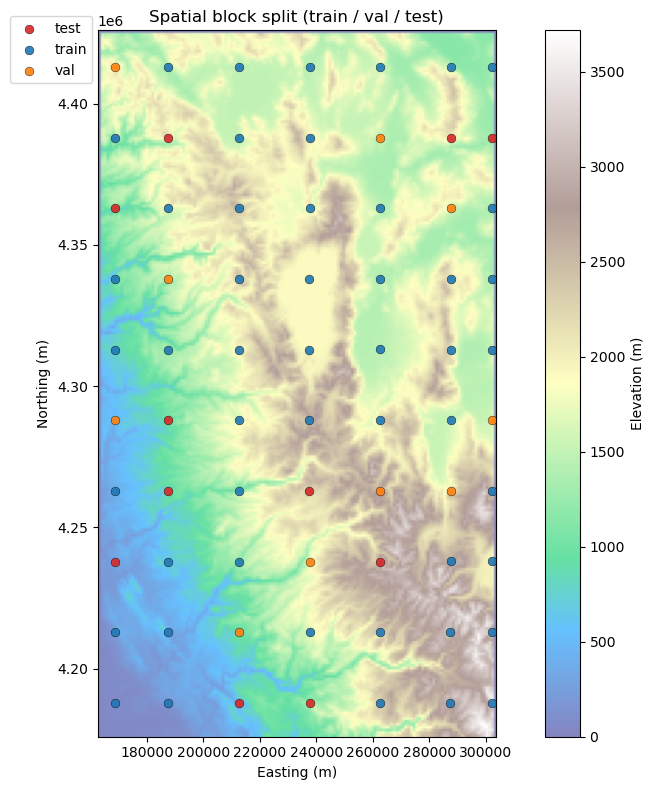

Saved ML input table to: C:\Users\EmmaGolub\Desktop\MRoS_local\local_data\ML_pipeline\compiled_input_predictors\withKriging_v4\ml_input_withKriging.parquet


In [24]:
# Visualize spatial block split over DEM

# Select DEM
dem = ds_interp["elev"]  # our DEM exists in any of the interpolated datasets

# Handle nodata if present
dem_vals = dem.values
if "_FillValue" in dem.attrs:
    dem_vals = np.where(dem_vals == dem.attrs["_FillValue"], np.nan, dem_vals)

# Compute spatial extent from coords
extent = [
    float(dem["x"].min()),
    float(dem["x"].max()),
    float(dem["y"].min()),
    float(dem["y"].max())
]

# Decide origin based on y direction
if float(dem["y"][0]) > float(dem["y"][-1]):
    # y decreases from north to south → put row 0 at the top (max y)
    origin = "upper"
else:
    origin = "lower"

# Spatial diagnostics
block_df = (
    master_df.groupby("block_id")
      .agg(
          x_mean=("x", "mean"),
          y_mean=("y", "mean"),
          split=("split", "first"),
          n=("phase_full", "size")
      )
      .reset_index()
)

colors = {"train": "tab:blue", "val": "tab:orange", "test": "tab:red"}

fig, ax = plt.subplots(figsize=(10, 8))

# DEM underlay
im = ax.imshow(
    dem_vals,
    extent=extent,
    origin=origin,
    cmap="terrain",
    alpha=0.6
)

# Block centroids
for split, g in block_df.groupby("split"):
    ax.scatter(
        g["x_mean"], g["y_mean"],
        s=40,
        c=colors[split],
        label=split,
        alpha=0.9,
        edgecolor="k",
        linewidths=0.3
    )

ax.legend(
    loc="upper left",
    bbox_to_anchor=(-0.22, 1.02),  # left of axes, slightly above
    frameon=True,
    borderaxespad=0.0
)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Spatial block split (train / val / test)")
ax.set_aspect("equal")

cbar = fig.colorbar(im, ax=ax, label="Elevation (m)")
fig.tight_layout()
fig.savefig(GRAPHICS_DIR / f"spatial_block_split_{interp_type}.png", dpi=200, bbox_inches="tight")
plt.show()

master_df.groupby("split").size().rename("n_samples")

if interp_type == "IDW":
    out_parquet = SETUP_DIR / "ml_input_withIDW.parquet"
elif interp_type == "kriging":
    out_parquet = SETUP_DIR / "ml_input_withKriging.parquet"
else:
    raise ValueError(f"Unknown interp_type: {interp_type}")
master_df.to_parquet(out_parquet, index=False)
print("Saved ML input table to:", out_parquet)


## Step 6: XGBoost Model Architecture

Gradient-boosted decision trees for multiclass regression.

Structurally:

- The model is an ensemble of decision trees.
- Each tree is shallow (max_depth = 6).
- Trees are added sequentially.
- Each new tree corrects the residual errors of the previous ensemble.

### Prepare features, target, train, val, and testing datasets + uncertainties

In [25]:
FEATURES = [
    # station-interpolated thermo
    "temp_wet", "temp_dew", "rh",

    # precip products
    "imerg_plp",

    # topography
    "elev",

    # discrepancy features (capturing station and PRISM datasets)
    "t_air_anom",
]

TARGET_FULL   = "phase_full"

# Prepare matrices
# Train on ALL labeled rows (including mix)
train_df = master_df[master_df["split"] == "train"].copy()
val_df   = master_df[master_df["split"] == "val"].copy()
test_df  = master_df[master_df["split"] == "test"].copy()

# Features
X_train = train_df[FEATURES]
X_val   = val_df[FEATURES]
X_test  = test_df[FEATURES]

# True 3-class target
y_train = train_df["phase_full"].astype(int)
y_val   = val_df["phase_full"].astype(int)
y_test  = test_df["phase_full"].astype(int)

# Keep v3 label confidence weighting (applies to all classes)
c_train = train_df["label_confidence"].values
c_val   = val_df["label_confidence"].values

# Keep v3 transition-window upweighting (0–4°C wet-bulb)
tw_train = train_df["temp_wet"].values
tw_val   = val_df["temp_wet"].values

print("Train phase_full counts:\n", y_train.value_counts())
print("Val phase_full counts:\n", y_val.value_counts())
print("Test phase_full counts:\n", y_test.value_counts())

Train phase_full counts:
 phase_full
1    6491858
0    6318069
2    3738833
Name: count, dtype: int64
Val phase_full counts:
 phase_full
1    1425885
0    1279016
2     735716
Name: count, dtype: int64
Test phase_full counts:
 phase_full
1    1555896
0    1413694
2     949989
Name: count, dtype: int64


### Class weighting to handle imbalance

In [26]:
# Handle class imbalance... compute class weights from training set

classes = np.array([0, 1, 2])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train.values
)
class_weight = dict(zip(classes, weights))
print("Class weights:", class_weight)

# Base weights from imbalance
w_train = y_train.map(class_weight).values
w_val   = y_val.map(class_weight).values

# Multiply by label confidence (v3 improvement)
w_train = w_train * c_train
w_val   = w_val   * c_val

# Transition-window upweight (v3 improvement)
alpha = 1.0  # same knob you used in v3
trans_train = (tw_train >= 0.0) & (tw_train <= 4.0)
trans_val   = (tw_val   >= 0.0) & (tw_val   <= 4.0)

w_train = w_train * (1.0 + alpha * trans_train.astype(float))
w_val   = w_val   * (1.0 + alpha * trans_val.astype(float))
print("Sample weights stats:")

Class weights: {np.int64(0): np.float64(0.8730916571714132), np.int64(1): np.float64(0.8497187297278119), np.int64(2): np.float64(1.4753944167426931)}
Sample weights stats:


### Train!

[0]	train-mlogloss:1.03602	val-mlogloss:1.03489
[50]	train-mlogloss:0.79466	val-mlogloss:0.81302
[100]	train-mlogloss:0.76099	val-mlogloss:0.78446
[150]	train-mlogloss:0.74691	val-mlogloss:0.77394
[200]	train-mlogloss:0.73753	val-mlogloss:0.76738
[250]	train-mlogloss:0.73076	val-mlogloss:0.76306
[300]	train-mlogloss:0.72510	val-mlogloss:0.75963
[350]	train-mlogloss:0.72008	val-mlogloss:0.75674
[400]	train-mlogloss:0.71526	val-mlogloss:0.75387
[450]	train-mlogloss:0.71091	val-mlogloss:0.75131
[500]	train-mlogloss:0.70699	val-mlogloss:0.74913
[550]	train-mlogloss:0.70324	val-mlogloss:0.74688
[600]	train-mlogloss:0.69950	val-mlogloss:0.74474
[650]	train-mlogloss:0.69609	val-mlogloss:0.74282
[700]	train-mlogloss:0.69280	val-mlogloss:0.74084
[750]	train-mlogloss:0.68969	val-mlogloss:0.73915
[800]	train-mlogloss:0.68639	val-mlogloss:0.73730
[850]	train-mlogloss:0.68326	val-mlogloss:0.73544
[900]	train-mlogloss:0.68063	val-mlogloss:0.73400
[950]	train-mlogloss:0.67796	val-mlogloss:0.73244
[10

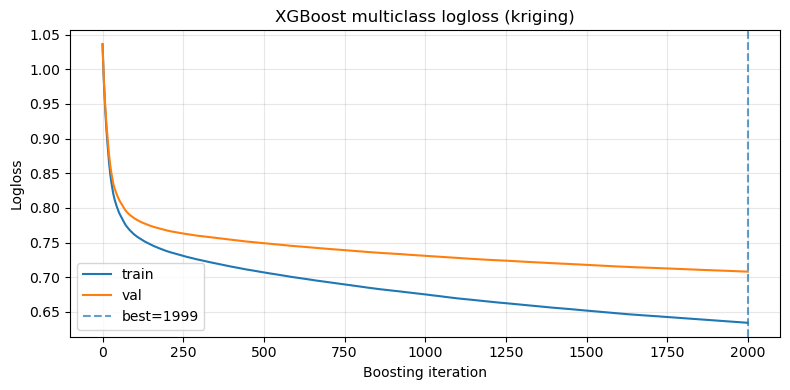

In [27]:
# ~62 minutes to run

params = {
    "objective": "multi:softprob",
    "num_class": 3,
    "eval_metric": "mlogloss",
    "max_depth": 6,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "lambda": 1.0,
    "tree_method": "hist",
    "seed": 42,
}

dtrain = xgb.DMatrix(X_train, label=y_train, weight=w_train)
dval   = xgb.DMatrix(X_val,   label=y_val,   weight=w_val)

evals = [(dtrain, "train"), (dval, "val")]
evals_result = {}

booster = xgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    evals=evals,
    evals_result=evals_result,
    early_stopping_rounds=50,
    verbose_eval=50,
)

print("Best iteration:", booster.best_iteration)
print("Best score:", booster.best_score)

# Loss curves
train_loss = evals_result["train"]["mlogloss"]
val_loss   = evals_result["val"]["mlogloss"]

plt.figure(figsize=(8,4))
plt.plot(train_loss, label="train")
plt.plot(val_loss, label="val")
plt.axvline(booster.best_iteration, ls="--", alpha=0.7, label=f"best={booster.best_iteration}")
plt.xlabel("Boosting iteration")
plt.ylabel("Logloss")
plt.title(f"XGBoost multiclass logloss ({interp_type})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Predict on test

In [28]:
# ============================================================
# PREDICT (3-class): probabilities + hard class
# ============================================================

# “Does the model’s uncertainty band align with the proxy-defined transition regime?”

dtest = xgb.DMatrix(X_test)
y_test_prob = booster.predict(dtest)  # shape: (n, 3)
y_test_pred = np.argmax(y_test_prob, axis=1)

# Prob columns: 0 snow, 1 rain, 2 mix
p_snow = y_test_prob[:, 0]
p_rain = y_test_prob[:, 1]
p_mix  = y_test_prob[:, 2]

max_prob = np.max(y_test_prob, axis=1)
ent = entropy(y_test_prob.T, base=2)  # higher = more uncertain

print("Confusion matrix:\n", confusion_matrix(y_test, y_test_pred))
print(classification_report(
    y_test, y_test_pred,
    target_names=["snow", "rain", "mix"],
    digits=3
))

# Attach predictions back onto test_df
df_test = test_df.copy()
df_test["prediction"] = y_test_pred
df_test["p_snow"] = p_snow
df_test["p_rain"] = p_rain
df_test["p_mix"]  = p_mix
df_test["max_prob"] = max_prob
df_test["entropy"] = ent


Confusion matrix:
 [[1123301  240818   49575]
 [ 257202 1240197   58497]
 [ 450908  332244  166837]]
              precision    recall  f1-score   support

        snow      0.613     0.795     0.692   1413694
        rain      0.684     0.797     0.736   1555896
         mix      0.607     0.176     0.272    949989

    accuracy                          0.646   3919579
   macro avg      0.635     0.589     0.567   3919579
weighted avg      0.640     0.646     0.608   3919579



In [29]:
# Export and Save

model_path = MODEL_OUT_DIR / "xgb_phase_model.bin"
booster.save_model(model_path)

feature_names = list(X_train.columns)
with open(MODEL_OUT_DIR / "feature_names.json", "w") as f:
    json.dump(feature_names, f, indent=2)

# Save representative feature matrix + labels (optional but useful)
X_test.to_parquet(MODEL_OUT_DIR / "X_test.parquet")
y_test.to_frame(name="phase_full").to_parquet(MODEL_OUT_DIR / "y_test.parquet")

# Save compact prediction output
df_test_out = df_test[
    ["time", "x", "y", "phase_full", "prediction",
     "p_snow", "p_rain", "p_mix", "max_prob", "entropy", "block_id"]
].rename(columns={"phase_full": "phase"})

df_test_out.to_parquet(MODEL_OUT_DIR / "test_predictions.parquet")
df_test.to_parquet(MODEL_OUT_DIR / "X_test_predictions_combined.parquet")

metadata = {
    "classes": {"0": "snow", "1": "rain", "2": "mix"},
    "model_type": "XGBoost (multi:softprob)",
    "spatial_blocking": "random block split (~25-50 km blocks)",
    "training_period": "2024-10-11 to 2025-05-30",
    "label_definition": {"snow": "proxy <= 20", "rain": "proxy >= 80", "mix": "20 < proxy < 80"},
    "weights": {
        "class_weight_balanced": {
            int(k): float(v) for k, v in class_weight.items()},
        "label_confidence_multiplier": True,
        "transition_window_temp_wet_C": [0, 4],
        "transition_alpha": float(alpha),
    },
}

with open(MODEL_OUT_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved model + artifacts to:", MODEL_OUT_DIR)

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_42968\1723353935.py:4: UserWarning: [15:20:30] WARNING: D:\bld\xgboost-split_1765326876395\work\src\c_api\c_api.cc:1575: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  booster.save_model(model_path)


Saved model + artifacts to: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withKriging_v4
